In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def import_survey_data(path, sort=True):
    df = pd.read_csv(path, sep=',')
    if sort:
        df = df.sort_values(by=df.columns[1], ascending=False)
    # get first column

    category_names = df[df.columns[0]].tolist()
    results = {'Test':df[df.columns[1]].tolist()}
    return results, category_names


def aggregate_by_threshold(data_array, category_names, threshold_perc):
    if threshold_perc <= 0 or len(category_names) < 2:
        return data_array, category_names

    # 1. Calculate the average proportion of each category across all questions
    #    We sum the counts for each category (column) and then divide by the total overall sum.
    total_responses = data_array.sum()
    category_proportions = data_array.sum(axis=0) / total_responses * 100 
    
    # 2. Identify the indices of categories to merge (those below the threshold)
    merge_indices = np.where(category_proportions < threshold_perc)[0]
    
    if len(merge_indices) == 0:
        return data_array, category_names
    
    # 3. Create the merged 'Other' data
    merged_data = data_array[:, merge_indices].sum(axis=1)
    
    # 4. Identify indices of categories to keep
    kept_indices = [i for i in range(data_array.shape[1]) if i not in merge_indices]
    
    # 5. Build the new data array: Kept columns + new 'Other' column
    # np.newaxis converts the 1D merged_data into a column vector for hstack
    new_data = np.hstack((data_array[:, kept_indices], merged_data[:, np.newaxis]))
    
    # 6. Build the new category names list
    new_category_names = [category_names[i] for i in kept_indices]
    new_category_names.append('Other')
    
    return new_data, new_category_names


def survey(results, category_names, global_font_size=12, label_n_cols=4, fig_size=(9.2, 5), threshold_perc=0, save_pdf=None, colors='RdYlGn_r'):
    # Global font config
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams["font.size"] = global_font_size
    plt.rcParams['axes.edgecolor'] = '#333F4B'
    plt.rcParams['axes.linewidth'] = 0.8

    labels = list(results.keys())
    data = np.array(list(results.values()))

    # --- AGGREGATION CALL ---
    data, category_names = aggregate_by_threshold(data, category_names, threshold_perc)
    
    # --- DATA NORMALIZATION (to percentage) ---
    data_sum = data.sum(axis=1)
    # Safety check: replace 0 sums with 1 to prevent division by zero
    data_sum[data_sum == 0] = 1 
    data = data / data_sum[:, np.newaxis] * 100
    
    data_cum = data.cumsum(axis=1)
    
    # Recalculate colors based on the potentially new number of categories
    category_colors = plt.colormaps[colors](
        np.linspace(0.15, 0.85, data.shape[1]))

    # --- PLOT SETUP ---
    fig, ax = plt.subplots(figsize=fig_size, dpi=300)
    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    
    # X-limit is set to 100 since data is normalized to percentages
    ax.set_xlim(0, 100) 

    # Hide Y-axis labels and ticks
    ax.set_yticklabels([])
    ax.tick_params(axis='y', length=0)

    # Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # --- DRAW BARS ---
    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        
        # 1. Plot the bar segments
        rects = ax.barh(labels, widths, left=starts, height=0.5,
                        label=colname, color=color)

        # 2. Plot the bar values (inside the bar)
        # r, g, b, _ = color
        # text_color = 'white' if r * g * b < 0.5 else 'darkgrey'
        text_color = 'black'  # Use black text for better visibility
        
        # Use %.1f%% format with a smaller font size
        ax.bar_label(rects, label_type='center', color=text_color, 
                     fmt='%.1f%%', fontsize=global_font_size * 0.65) 

    # --- LEGEND ---
    ax.legend(ncols=label_n_cols, bbox_to_anchor=(0, 1.05), loc='lower left', 
              fontsize='small', frameon=False, handlelength=0.9, handleheight=0.9)

    if save_pdf is not None:
        plt.savefig(save_pdf + '.pdf', bbox_inches='tight')
    plt.show()


colormaps = {
    "Diverging": [
        "PuOr",
        "BrBG",
        "seismic",
        "RdYlGn"
    ],
    "Sequential": [
        "viridis",
        "Blues",
        "magma"
    ],
    "Qualitative": [
        "tab10",
        "Paired",
        "Dark2"
    ]
}

In [17]:
filename = 'attack_technique'
results, category_names = import_survey_data(filename + '.csv')

survey(
    results, 
    category_names, 
    label_n_cols=5, 
    fig_size=(10.5, 0.2), 
    threshold_perc=10, 
    save_pdf=filename)

FileNotFoundError: [Errno 2] No such file or directory: 'attack_technique.csv'

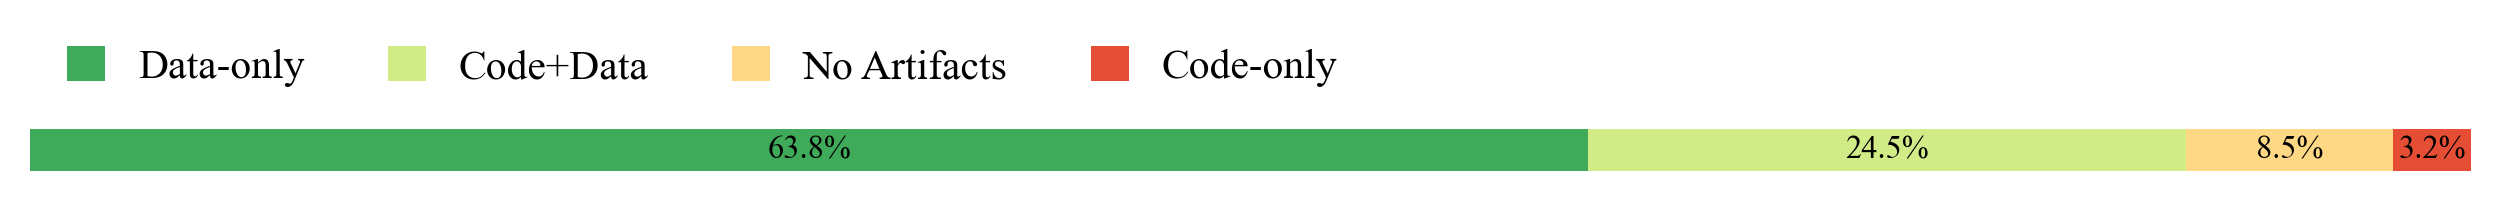

In [3]:
filename = 'code_data'
results, category_names = import_survey_data(filename + '.csv')

survey(
    results, 
    category_names, 
    label_n_cols=5, 
    fig_size=(10.5, 0.2), 
    threshold_perc=0, 
    save_pdf=filename)

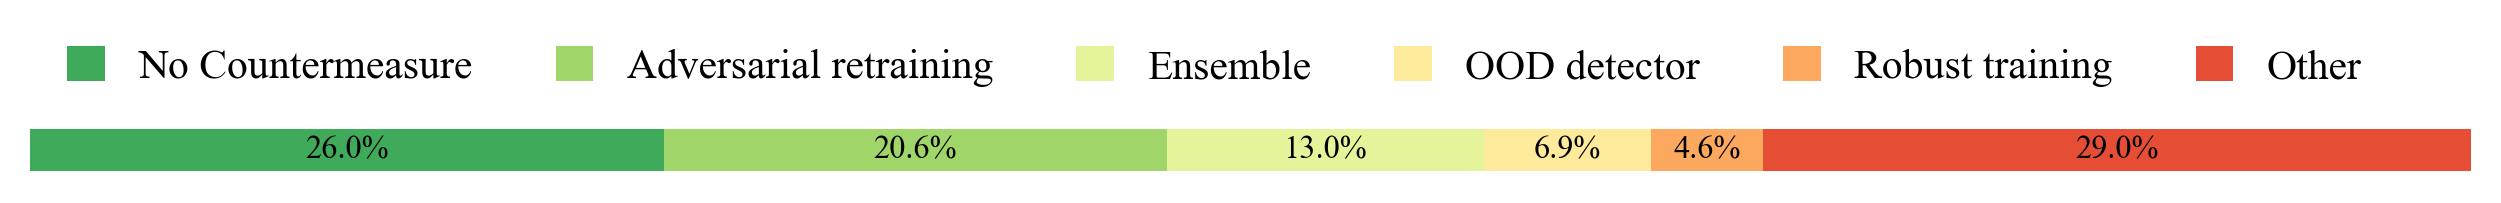

In [4]:
filename = 'defense_technique'
results, category_names = import_survey_data(filename + '.csv')

survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=(10.5, 0.2), 
    threshold_perc=4, 
    save_pdf=filename)

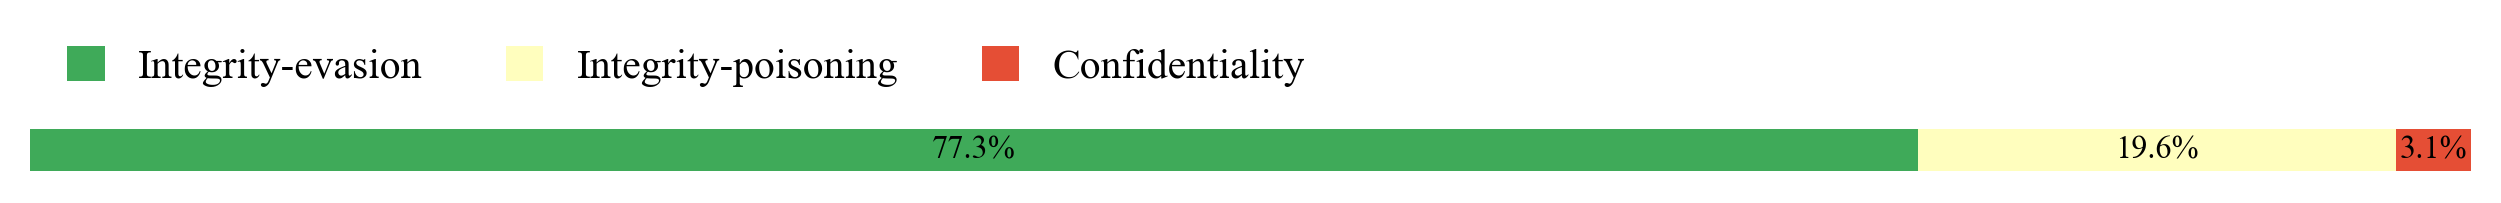

In [5]:
filename = 'goal'
results, category_names = import_survey_data(filename + '.csv')
survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=(10.5, 0.2), 
    threshold_perc=0, 
    save_pdf=filename)

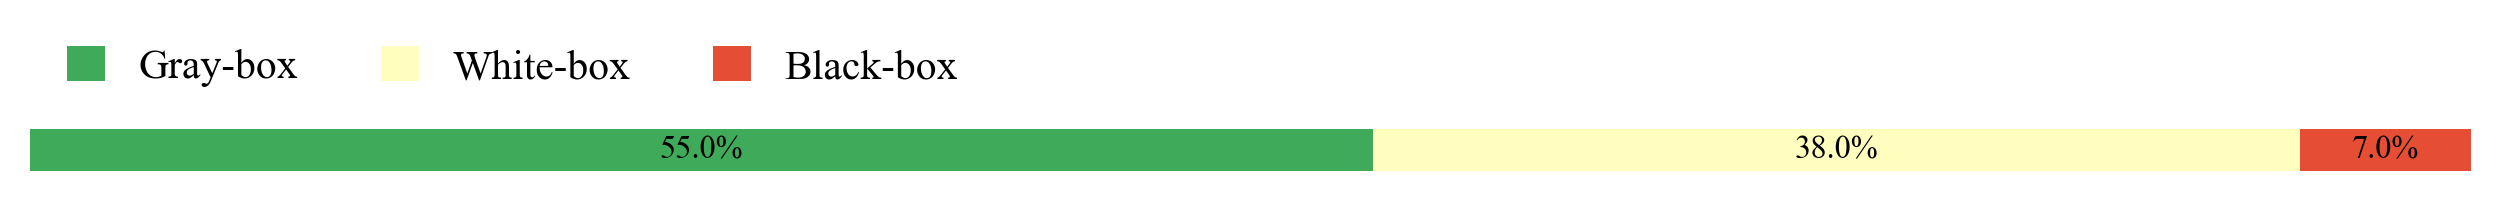

In [6]:
filename = 'knowledge'
results, category_names = import_survey_data(filename + '.csv')
survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=(10.5, 0.2), 
    threshold_perc=0, 
    save_pdf=filename)

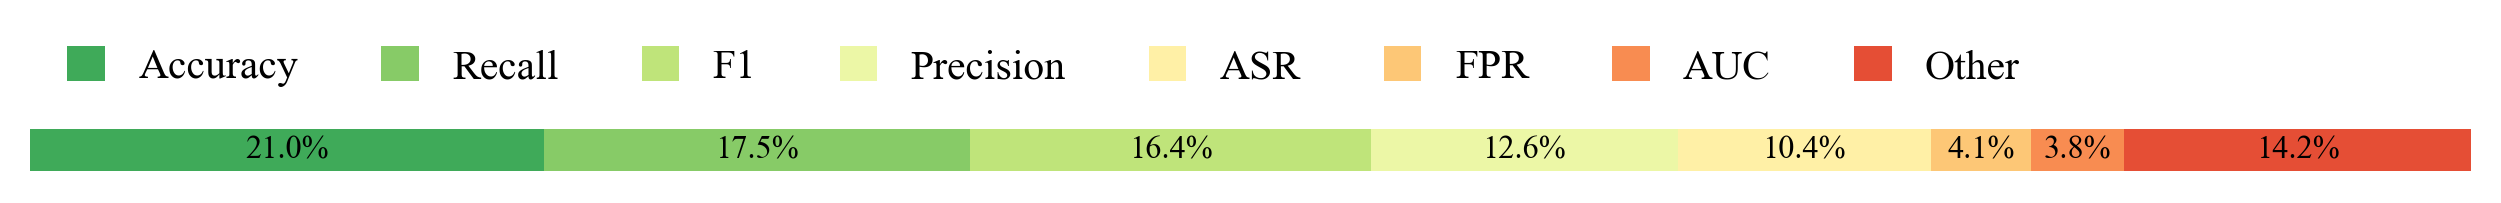

In [7]:
filename = 'metrics'
results, category_names = import_survey_data(filename + '.csv') 
survey(
    results, 
    category_names, 
    label_n_cols=8, 
    fig_size=(10.5, 0.2), 
    threshold_perc=3, 
    save_pdf=filename)

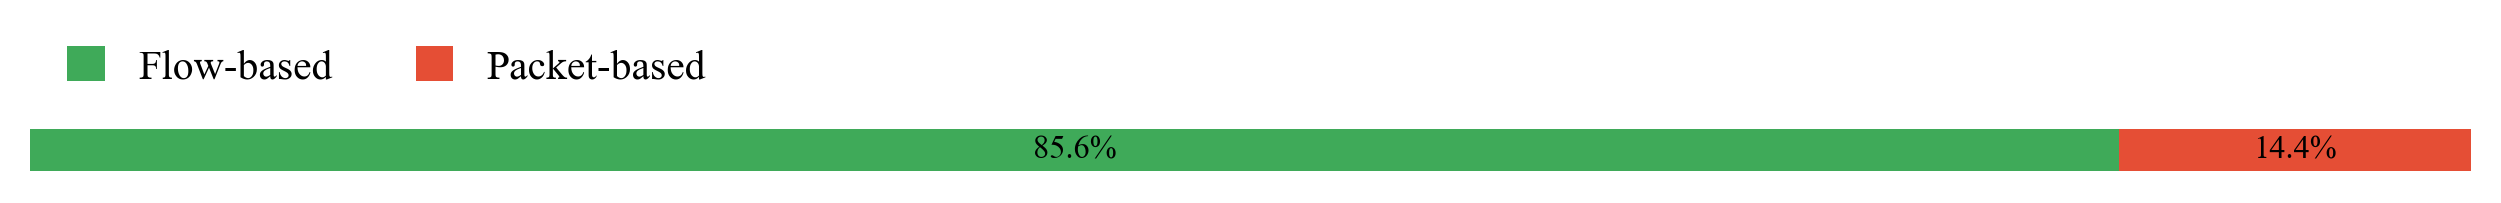

In [8]:
filename = 'nids_granularity'
results, category_names = import_survey_data(filename + '.csv') # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=(10.5, 0.2), 
    threshold_perc=0, 
    save_pdf=filename)

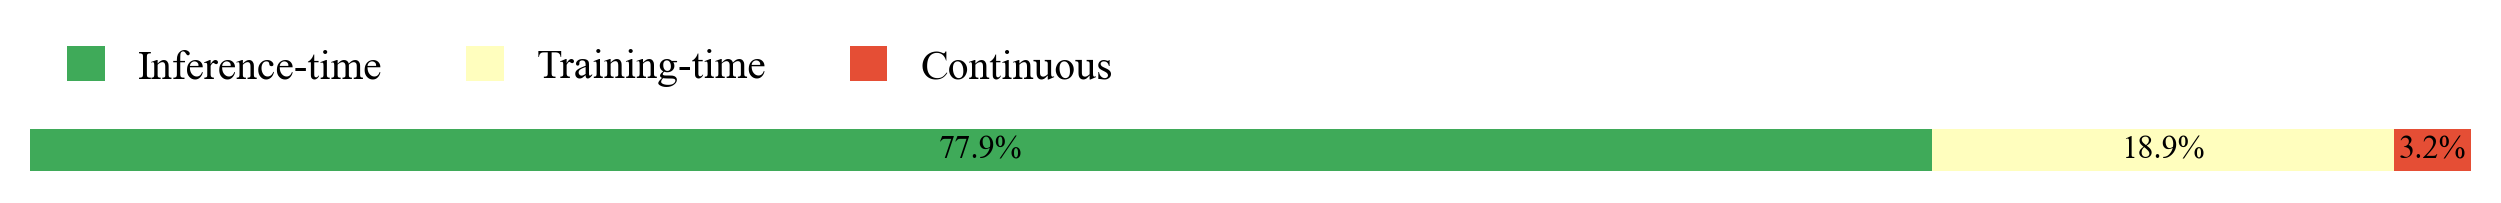

In [9]:
filename = 'phase'
results, category_names = import_survey_data(filename + '.csv') # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=(10.5, 0.2), 
    threshold_perc=0, 
    save_pdf=filename)

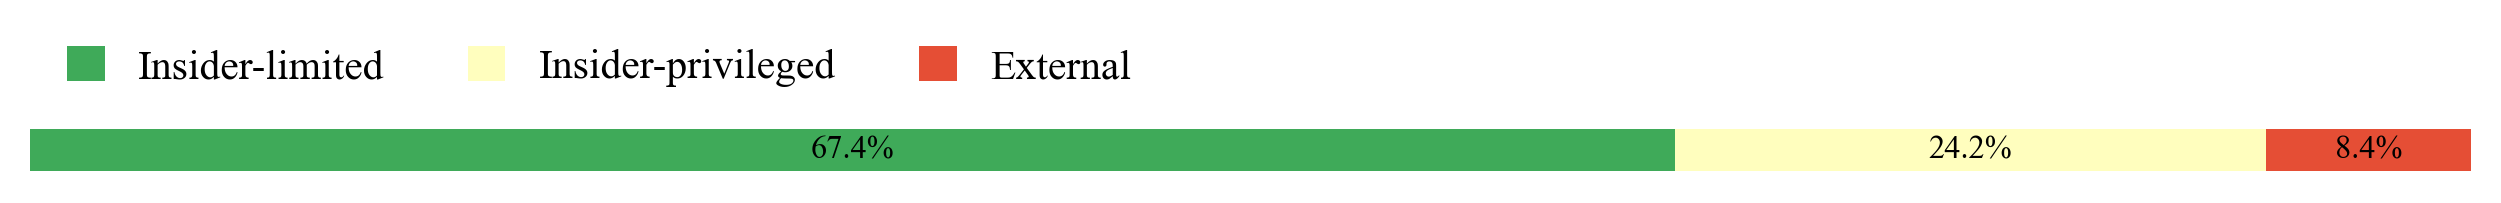

In [10]:
filename = 'position'
results, category_names = import_survey_data(filename + '.csv') # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=(10.5, 0.2), 
    threshold_perc=0, 
    save_pdf=filename)

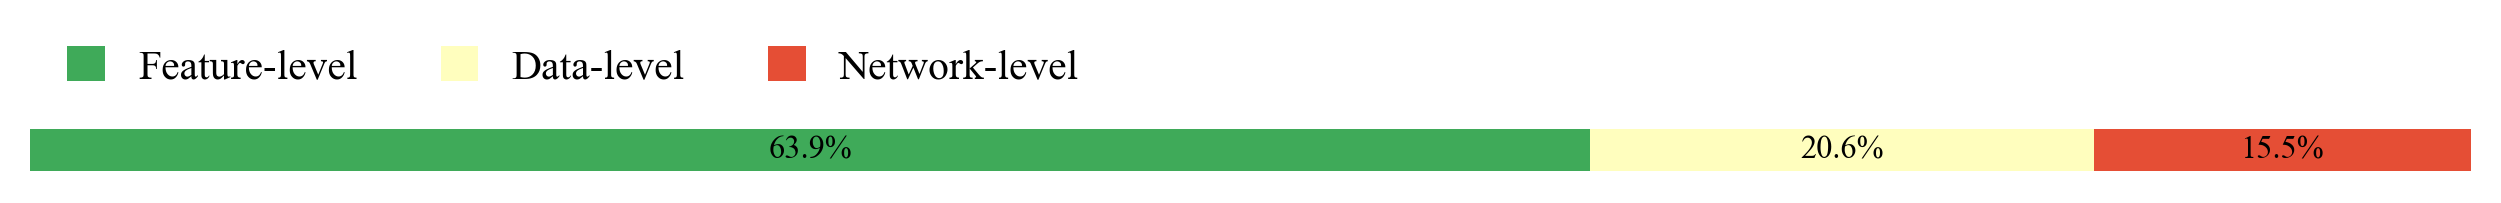

In [11]:
filename = 'surface'
results, category_names = import_survey_data(filename + '.csv') # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=(10.5, 0.2), 
    threshold_perc=0, 
    save_pdf=filename)

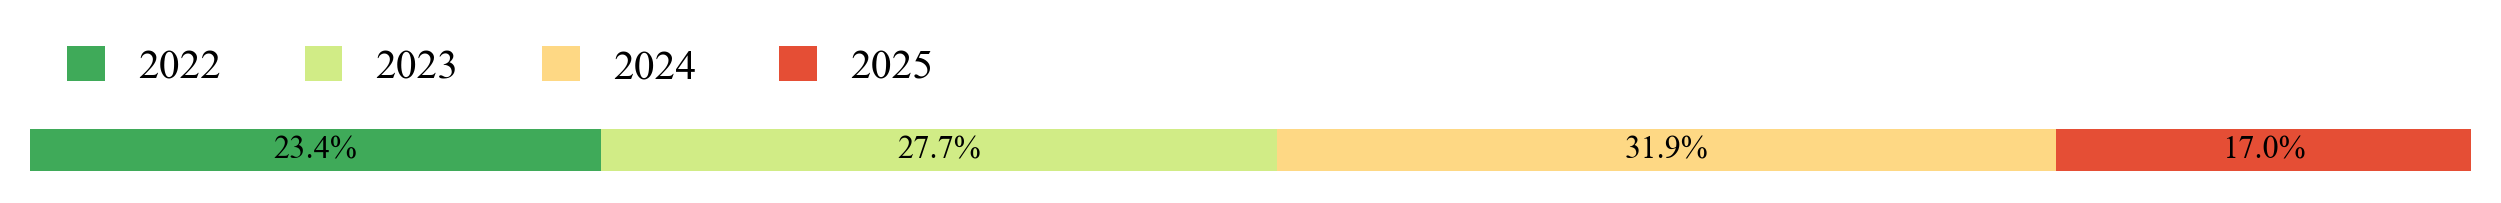

In [12]:
filename = 'year'
results, category_names = import_survey_data(filename + '.csv', sort=False) # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=(10.5, 0.2), 
    threshold_perc=0, 
    save_pdf=filename)

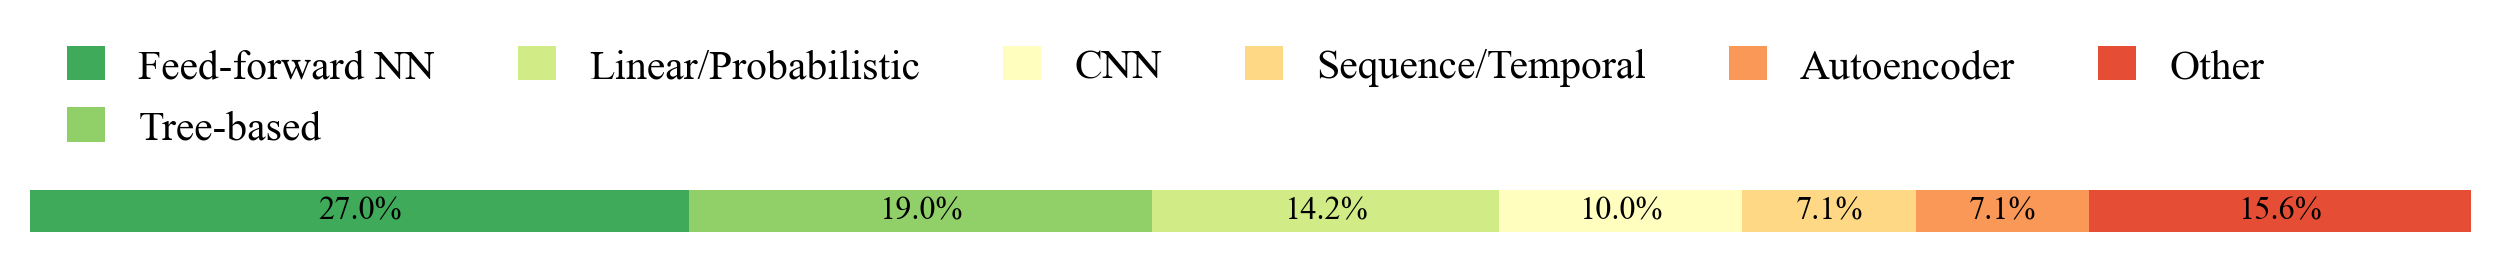

In [13]:
filename = 'models'
results, category_names = import_survey_data(filename + '.csv', sort=False) # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=6, 
    fig_size=(10.5, 0.2), 
    threshold_perc=6, 
    save_pdf=filename)

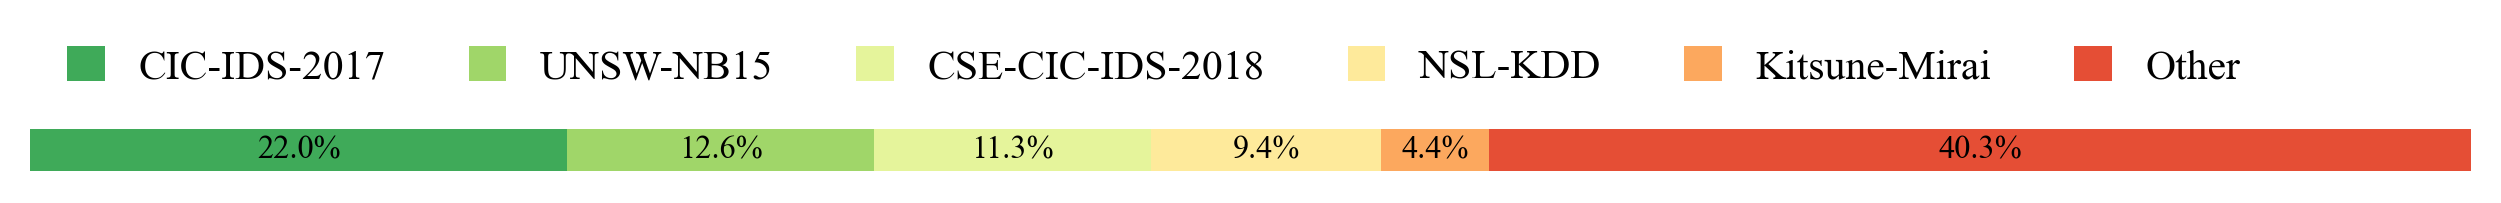

In [14]:
filename = 'datasets'
results, category_names = import_survey_data(filename + '.csv', sort=True) # This line should be outside the survey function

survey(
    results, 
    category_names, 
    label_n_cols=7, 
    fig_size=(10.5, 0.2), 
    threshold_perc=4, 
    save_pdf=filename)